In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
model = load_model("../models/densenet121_final.keras", compile=False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
DATASET_DIR = "../data/images"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 503 images belonging to 6 classes.


In [8]:
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)


32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step


In [9]:
# Grad-CAM settings
LAST_CONV_LAYER_NAME = "conv5_block16_concat"


def get_img_array(img_path, size):
    img = image.load_img(img_path, target_size=size)
    array = image.img_to_array(img)
    array = array / 255.0
    array = np.expand_dims(array, axis=0)
    return array


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to:
    # 1) activations of the last conv layer
    # 2) final predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # Gradient of the class score with respect to conv outputs
    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling on gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the conv feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU to keep only positive influence
    heatmap = tf.maximum(heatmap, 0)

    # Normalize between 0 and 1
    max_val = tf.reduce_max(heatmap)
    if max_val == 0:
        return np.zeros_like(heatmap.numpy())

    heatmap = heatmap / max_val
    return heatmap.numpy()


def overlay_heatmap_on_image(img_path, heatmap, alpha=0.4):
    # Load original image with cv2
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize heatmap to match original image size
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert heatmap to 0-255
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    # Apply colormap
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # Overlay heatmap on image
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)

    return img, heatmap_resized, overlay

In [10]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.93      0.80      0.86        80
       glass       0.82      0.80      0.81       100
       metal       0.83      0.90      0.87        82
       paper       0.89      0.93      0.91       118
     plastic       0.80      0.73      0.76        96
       trash       0.57      0.78      0.66        27

    accuracy                           0.83       503
   macro avg       0.81      0.82      0.81       503
weighted avg       0.84      0.83      0.83       503



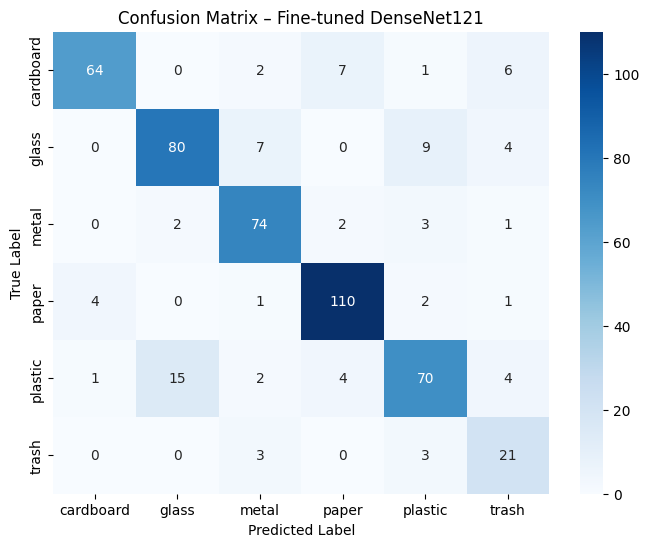

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Fine-tuned DenseNet121")
plt.show()


In [12]:
WASTE_ACTIONS = {
    "cardboard": "Send to recycling facility",
    "paper": "Send to recycling facility",
    "glass": "Handle separately – glass recycling",
    "metal": "Metal recovery process",
    "plastic": "Plastic sorting and recycling",
    "trash": "Send to landfill"
}


In [13]:
def decision_support(predicted_class, confidence):
    action = WASTE_ACTIONS[predicted_class]

    if confidence < 0.6:
        return "Manual inspection required"

    return action


In [17]:
# Select an image for prediction + explanation
img_path = "../data/images/plastic/plastic57.jpg"

# Prepare image
img_array = get_img_array(img_path, IMG_SIZE)

# Predict
pred = model.predict(img_array, verbose=0)
pred_index = int(np.argmax(pred[0]))
pred_class = class_names[pred_index]
confidence = float(np.max(pred[0]))

print(f"Predicted class: {pred_class}")
print(f"Confidence: {confidence:.2%}")
print("Suggested action:", decision_support(pred_class, confidence))

# Show all class probabilities
print("\nClass probabilities:")
for i, cls in enumerate(class_names):
    print(f"{cls}: {pred[0][i]:.4f}")

Predicted class: plastic
Confidence: 99.61%
Suggested action: Plastic sorting and recycling

Class probabilities:
cardboard: 0.0000
glass: 0.0027
metal: 0.0010
paper: 0.0000
plastic: 0.9961
trash: 0.0002


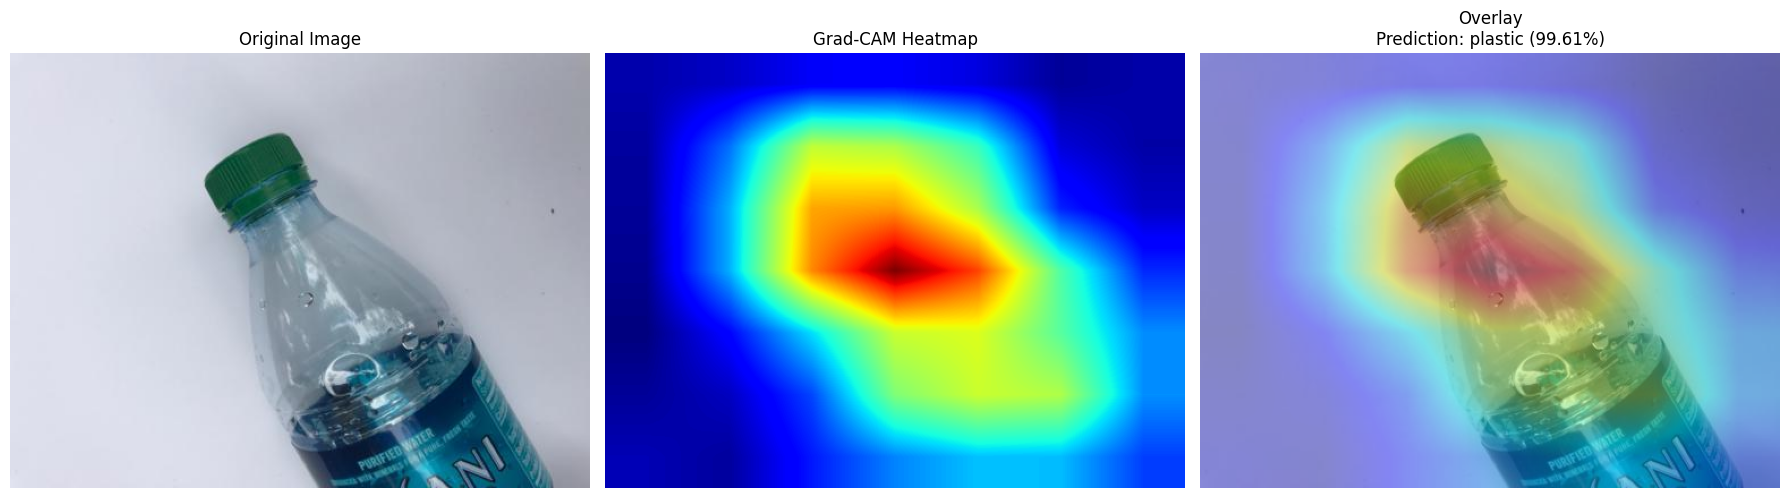

In [18]:
# Generate Grad-CAM heatmap
heatmap = make_gradcam_heatmap(
    img_array=img_array,
    model=model,
    last_conv_layer_name=LAST_CONV_LAYER_NAME,
    pred_index=pred_index
)

# Create overlay image
original_img, heatmap_resized, overlay_img = overlay_heatmap_on_image(img_path, heatmap, alpha=0.4)

# Display results
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_img)
plt.title(f"Overlay\nPrediction: {pred_class} ({confidence:.2%})")
plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
print("Interpretation:")
print(
    f"The model classified this image as '{pred_class}' with confidence {confidence:.2%}. "
    "The Grad-CAM heatmap highlights the image regions that contributed most to this prediction."
)
print(
    "Red/yellow areas indicate stronger influence on the model decision, while blue areas indicate weaker influence."
)

Interpretation:
The model classified this image as 'plastic' with confidence 99.61%. The Grad-CAM heatmap highlights the image regions that contributed most to this prediction.
Red/yellow areas indicate stronger influence on the model decision, while blue areas indicate weaker influence.
